# part_1 Import Libraries

In [28]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.model_selection import train_test_split

In [29]:
import kagglehub
import os

path = kagglehub.dataset_download("bhavikjikadara/handwritten-digit-recognition")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'handwritten-digit-recognition' dataset.
Path to dataset files: /kaggle/input/handwritten-digit-recognition


In [33]:
train_df = pd.read_csv(os.path.join(path, "train.csv"))
test_df = pd.read_csv(os.path.join(path, "test.csv"))
X = train_df.drop("label", axis=1).values #Feature
y = train_df["label"].values #label
X_test = test_df.values

In [34]:
X = X / 255.0
test = test_df.values / 255.0

In [35]:
X = X.reshape(-1, 28, 28, 1)
test = test.reshape(-1, 28, 28, 1)

Split data

In [36]:
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.1, random_state=42
)

CNN layer

In [39]:
model = models.Sequential([
    layers.RandomRotation(0.1),
    layers.RandomTranslation(0.1, 0.1),

    layers.Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128, (3,3), activation='relu'),

    layers.Flatten(),

    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),

    layers.Dense(10, activation='softmax')
])
# compile the model
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=10,
    batch_size=64
)

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ random_rotation_2               │ ?                      │   0 (unbuilt) │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_translation_2            │ ?                      │   0 (unbuilt) │
│ (RandomTranslation)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
591/591 ━━━━━━━━━━━━━━━━━━━━ 53s 84ms/step - accuracy: 0.7892 - loss: 0.6500 - val_accuracy: 0.9679 - val_loss: 0.1022
Epoch 2/10
591/591 ━━━━━━━━━━━━━━━━━━━━ 54s 92ms/step - accuracy: 0.9303 - loss: 0.2315 - val_accuracy: 0.9802 - val_loss: 0.0661
Epoch 3/10
591/591 ━━━━━━━━━━━━━━━━━━━━ 81s 91ms/step - accuracy: 0.9481 - loss: 0.1722 - val_accuracy: 0.9781 - val_loss: 0.0683
Epoch 4/10
591/591 ━━━━━━━━━━━━━━━━━━━━ 44s 75ms/step - accuracy: 0.9581 - loss: 0.1413 - val_accuracy: 0.9826 - val_loss: 0.0580
Epoch 5/10
591/591 ━━━━━━━━━━━━━━━━━━━━ 86s 82ms/step - accuracy: 0.9644 - loss: 0.1189 - val_accuracy: 0.9848 - val_loss: 0.0548
Epoch 6/10
591/591 ━━━━━━━━━━━━━━━━━━━━ 79s 76ms/step - accuracy: 0.9681 - loss: 0.1108 - val_accuracy: 0.9852 - val_loss: 0.0518
Epoch 7/10
591/591 ━━━━━━━━━━━━━━━━━━━━ 45s 77ms/step - accuracy: 0.9703 - loss: 0.1029 - val_accuracy: 0.9871 - val_loss: 0.0429
Epoch 8/10
591/591 ━━━━━━━━━━━━━━━━━━━━ 47s 79ms/step - accuracy: 0.9725 - loss: 0.0932 - 

Plot Accuracy and loss

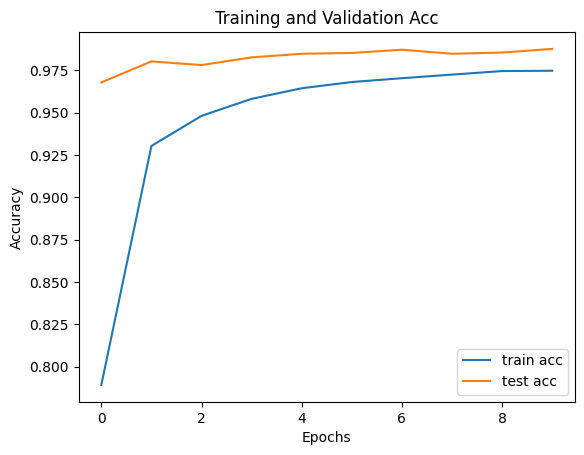

In [40]:
# Accuracy plot
plt.plot(history.history['accuracy'], label='train acc')
plt.plot(history.history['val_accuracy'], label='test acc')
plt.legend()
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training and Validation Acc')
plt.show()

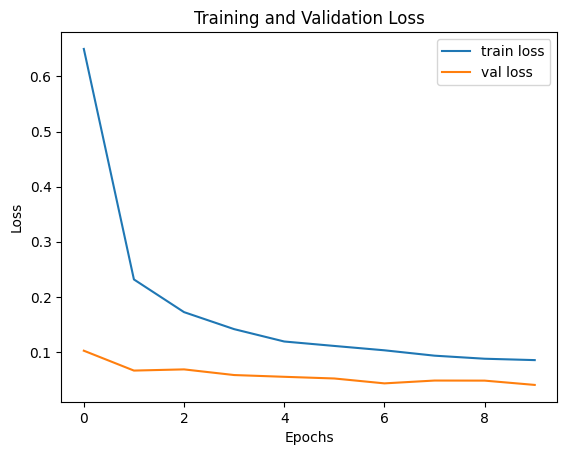

In [41]:
# plot loss
plt.plot(history.history['loss'], label='train loss')
plt.plot(history.history['val_loss'], label='val loss')
plt.legend()
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.show()

In [42]:
predictions = model.predict(test)
predicted_labels = np.argmax(predictions, axis=1)

875/875 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step


132/132 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step


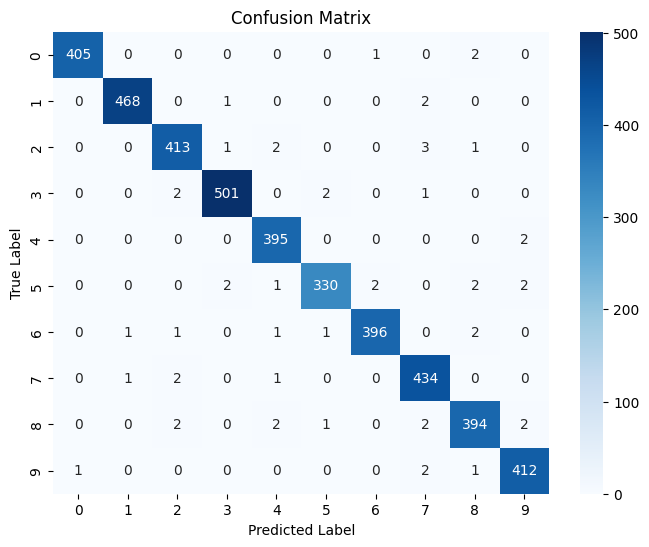

In [43]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

# Predict probabilities
predictions = model.predict(X_val)

# Convert probabilities to class labels
y_pred = np.argmax(predictions, axis=1)

cm = confusion_matrix(y_val, y_pred)

plt.figure(figsize=(8,6))

sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues',
            xticklabels=range(10),
            yticklabels=range(10))

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")

plt.show()

In [44]:
subFile = pd.DataFrame({
    "ImageId": np.arange(1, len(predicted_labels)+1),
    "Label": predicted_labels
})

subFile .to_csv("submission.csv", index=False)

print("Submission file saved!")

Submission file saved!


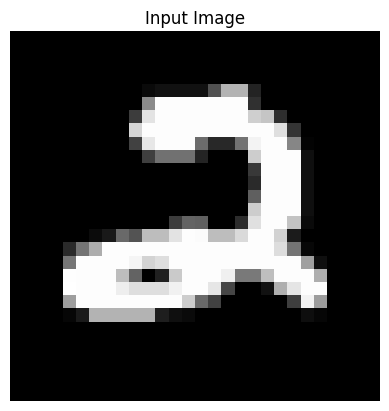

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
Predicted digit: 2


In [50]:
import numpy as np
import matplotlib.pyplot as plt

sample_display = test[0].reshape(28, 28)
plt.imshow(sample_display, cmap='gray')
plt.title("Input Image")
plt.axis('off')
plt.show()

# Get the first image for prediction
sample_input_for_model = test[0:1]
predictions = model.predict(sample_input_for_model)

print("Predicted digit:", np.argmax(predictions))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step


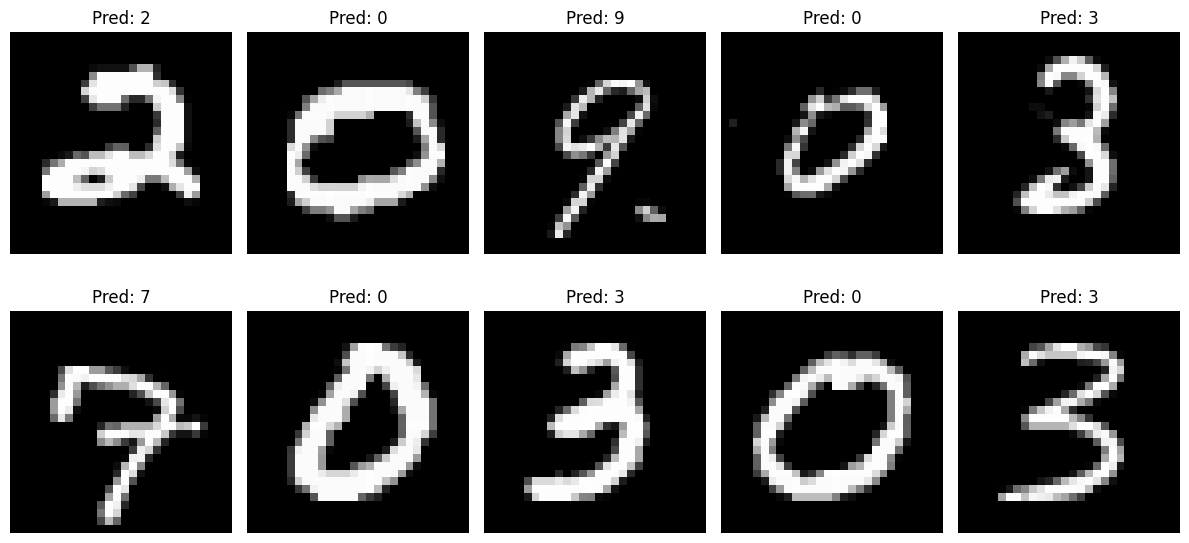

In [55]:
import numpy as np
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

for i in range(10):
    # Get the image for display (reshape to 2D for imshow)
    img_for_display = test[i].reshape(28, 28)

    # Get the image for prediction
    input_img_for_model = test[i:i+1]

    pred = model.predict(input_img_for_model)
    label = np.argmax(pred)

    plt.subplot(2, 5, i+1)
    plt.imshow(img_for_display, cmap='gray')
    plt.title(f"Pred: {label}")
    plt.axis('off')

plt.tight_layout()
plt.show()